## Below is a simple cell-by-cell notebook code for the Rainfall dataset that performs:

1️⃣ Data Extraction
2️⃣ Filling Missing Values (Imputation)
3️⃣ Scaling Numeric Features
4️⃣ Visualizing Feature Distribution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

##### Data import and dataload

In [3]:
df = pd.read_csv(r"E:\MLP\data\raw\district wise rainfall normal.csv")

df.head()

,STATE_UT_NAME,DISTRICT,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,ANDAMAN And NICOBAR ISLANDS,NICOBAR,107.3,57.9,65.2,117.0,358.5,295.5,285.0,271.9,354.8,326.0,315.2,250.9,2805.2,165.2,540.7,1207.2,892.1
1,ANDAMAN And NICOBAR ISLANDS,SOUTH ANDAMAN,43.7,26.0,18.6,90.5,374.4,457.2,421.3,423.1,455.6,301.2,275.8,128.3,3015.7,69.7,483.5,1757.2,705.3
2,ANDAMAN And NICOBAR ISLANDS,N & M ANDAMAN,32.7,15.9,8.6,53.4,343.6,503.3,465.4,460.9,454.8,276.1,198.6,100.0,2913.3,48.6,405.6,1884.4,574.7
3,ARUNACHAL PRADESH,LOHIT,42.2,80.8,176.4,358.5,306.4,447.0,660.1,427.8,313.6,167.1,34.1,29.8,3043.8,123.0,841.3,1848.5,231.0
4,ARUNACHAL PRADESH,EAST SIANG,33.3,79.5,105.9,216.5,323.0,738.3,990.9,711.2,568.0,206.9,29.5,31.7,4034.7,112.8,645.4,3008.4,268.1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 641 entries, 0 to 640
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   STATE_UT_NAME  641 non-null    str    
 1   DISTRICT       641 non-null    str    
 2   JAN            641 non-null    float64
 3   FEB            641 non-null    float64
 4   MAR            641 non-null    float64
 5   APR            641 non-null    float64
 6   MAY            641 non-null    float64
 7   JUN            641 non-null    float64
 8   JUL            641 non-null    float64
 9   AUG            641 non-null    float64
 10  SEP            641 non-null    float64
 11  OCT            641 non-null    float64
 12  NOV            641 non-null    float64
 13  DEC            641 non-null    float64
 14  ANNUAL         641 non-null    float64
 15  Jan-Feb        641 non-null    float64
 16  Mar-May        641 non-null    float64
 17  Jun-Sep        641 non-null    float64
 18  Oct-Dec        641 no

In [6]:
# missing values
df.isnull().sum().sum()

np.int64(0)

#### Select the feature

In [7]:
numeric_features = [
    "JAN","FEB","MAR","APR","MAY","JUN",
    "JUL","AUG","SEP","OCT","NOV","DEC",
    "Jan-Feb","Mar-May","Jun-Sep","Oct-Dec",
    "ANNUAL"
]

numeric_data = df[numeric_features]

In [8]:
imputer = SimpleImputer(strategy="mean")

numeric_data_imputed = pd.DataFrame(
    imputer.fit_transform(numeric_data),
    columns=numeric_features
)

#### Scale numeric  feature

In [9]:
scaler = StandardScaler()

scaled_data = pd.DataFrame(
    scaler.fit_transform(numeric_data_imputed),
    columns=numeric_features
)

scaled_data.head()

,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,ANNUAL
0,4.222132,1.332310,0.774298,0.999389,2.475708,0.506574,-0.185512,-0.126221,1.605882,3.143559,4.738016,7.120872,2.667897,1.798519,0.317087,5.034990,1.739666
1,1.203100,0.181017,-0.251781,0.628762,2.617833,1.329882,0.430695,0.865071,2.616381,2.812593,4.073877,3.369971,0.643560,1.530326,1.191711,3.779913,1.990792
2,0.680940,-0.183500,-0.471970,0.109884,2.342521,1.564603,0.630070,1.112894,2.608362,2.477623,2.772569,2.504144,0.196298,1.165077,1.393988,2.902434,1.868629
3,1.131896,2.158788,3.222795,4.376991,2.010001,1.277948,1.510301,0.895885,1.192860,1.022974,-0.000295,0.356401,1.773373,3.207938,1.336899,0.593174,2.024316
4,0.709422,2.111870,1.670465,2.390989,2.158384,2.761123,3.005835,2.753902,3.743169,1.554121,-0.077834,0.414531,1.557161,2.289424,3.181402,0.842442,3.206457


#### Visualize Distribution (Histogram)

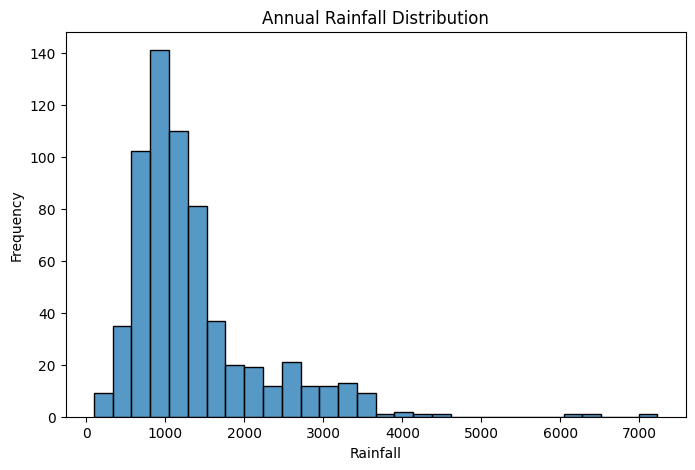

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["ANNUAL"], bins=30)

plt.title("Annual Rainfall Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")

plt.show()

#### Visualize Feature Distribution (Boxplot)

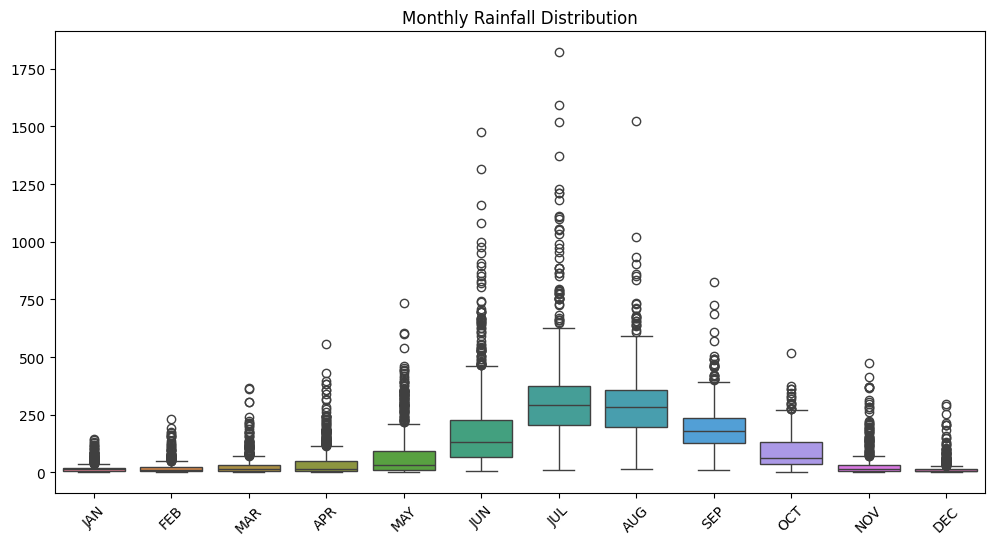

In [11]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[[
"JAN","FEB","MAR","APR","MAY","JUN",
"JUL","AUG","SEP","OCT","NOV","DEC"
]])

plt.xticks(rotation=45)

plt.title("Monthly Rainfall Distribution")

plt.show()

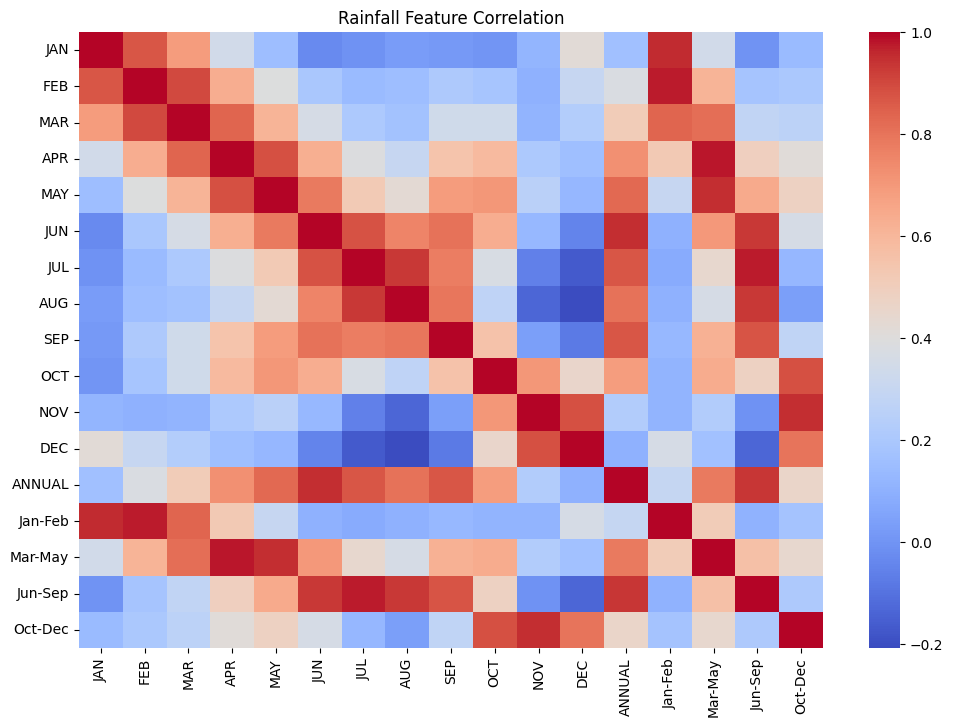

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Rainfall Feature Correlation")

plt.show()